In [1]:
import json, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")


All imports successful.


In [2]:
# Load and clean data
with open('rawComments.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Total records: {len(df)}")

df = df[~df['body'].isin(['[deleted]', '[removed]'])]
df = df[df['body'].notna()]
df = df[df['author'] != '[deleted]']
df = df[df['subreddit'].isin(['worldnews', 'politics', 'socialism'])]
df = df.reset_index(drop=True)

print(f"After cleaning: {len(df)}")
print(f"\nSubreddit counts:")
print(df['subreddit'].value_counts())

Total records: 5000
After cleaning: 4848

Subreddit counts:
subreddit
worldnews    3042
politics     1483
socialism     323
Name: count, dtype: int64


In [3]:
# Sentiment Analysis
os.makedirs('figures', exist_ok=True)
analyzer = SentimentIntensityAnalyzer()

def get_scores(text):
    s = analyzer.polarity_scores(text)
    return s['compound'], s['pos'], s['neg'], s['neu']

df[['compound','pos','neg','neu']] = df['body'].apply(lambda x: pd.Series(get_scores(x)))
df['sentiment'] = df['compound'].apply(lambda c: 'Positive' if c >= 0.05 else ('Negative' if c <= -0.05 else 'Neutral'))

summary = df.groupby('subreddit').agg(
    total=('compound','count'),
    avg_compound=('compound','mean'),
    pct_positive=('sentiment', lambda x: (x=='Positive').mean()*100),
    pct_neutral=('sentiment', lambda x: (x=='Neutral').mean()*100),
    pct_negative=('sentiment', lambda x: (x=='Negative').mean()*100)
).round(2)
print(summary.to_string())

           total  avg_compound  pct_positive  pct_neutral  pct_negative
subreddit                                                              
politics    1483         -0.05         40.59        16.12         43.29
socialism    323          0.06         48.61        15.17         36.22
worldnews   3042         -0.02         37.77        22.55         39.68


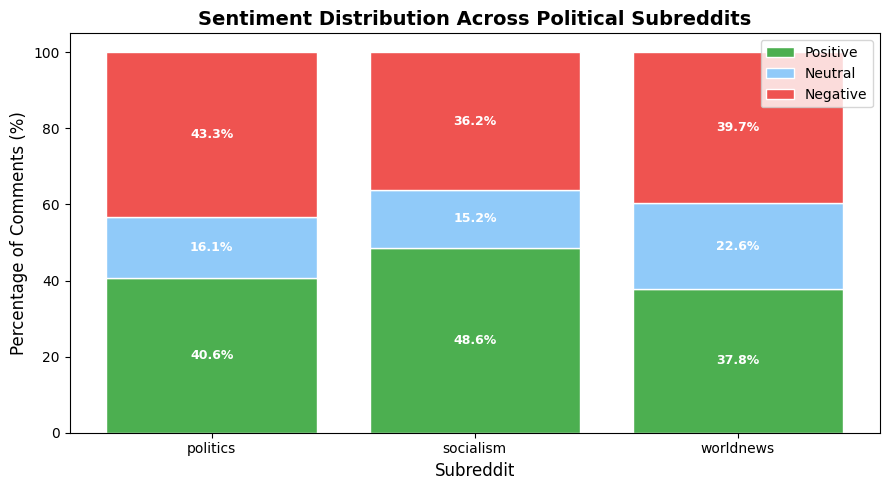

In [4]:
# Figure 1: Sentiment Distribution
sentiment_counts = df.groupby(['subreddit','sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100
subreddits = sentiment_counts.index.tolist()
categories = ['Positive', 'Neutral', 'Negative']
colors = ['#4CAF50', '#90CAF9', '#EF5350']

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(subreddits))
for cat, color in zip(categories, colors):
    if cat in sentiment_pct.columns:
        values = sentiment_pct[cat].values
        ax.bar(subreddits, values, bottom=bottom, color=color, label=cat, edgecolor='white')
        for i, (val, bot) in enumerate(zip(values, bottom)):
            if val > 5:
                ax.text(i, bot + val/2, f'{val:.1f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += values
ax.set_xlabel('Subreddit', fontsize=12)
ax.set_ylabel('Percentage of Comments (%)', fontsize=12)
ax.set_title('Sentiment Distribution Across Political Subreddits', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('figures/fig1_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

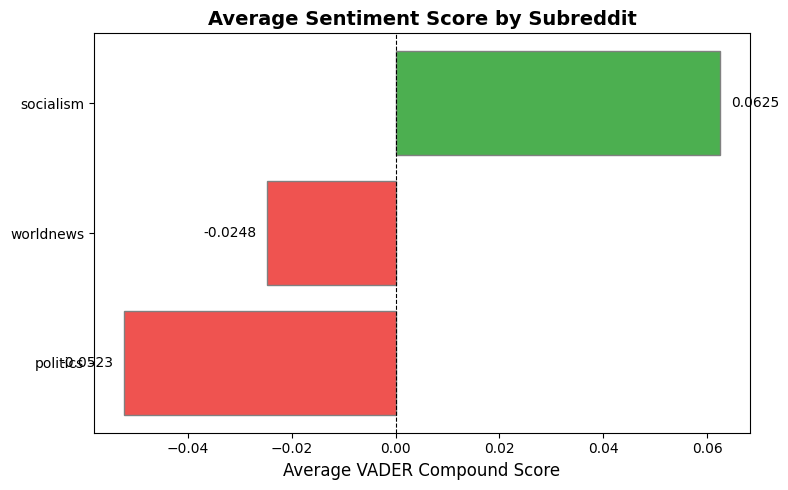

In [5]:
# Figure 2: Average Compound Score
fig, ax = plt.subplots(figsize=(8, 5))
avg_compound = df.groupby('subreddit')['compound'].mean().sort_values()
colors_bar = ['#EF5350' if v < 0 else '#4CAF50' for v in avg_compound.values]
bars = ax.barh(avg_compound.index, avg_compound.values, color=colors_bar, edgecolor='grey')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Average VADER Compound Score', fontsize=12)
ax.set_title('Average Sentiment Score by Subreddit', fontsize=14, fontweight='bold')
for bar, val in zip(bars, avg_compound.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig2_avg_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

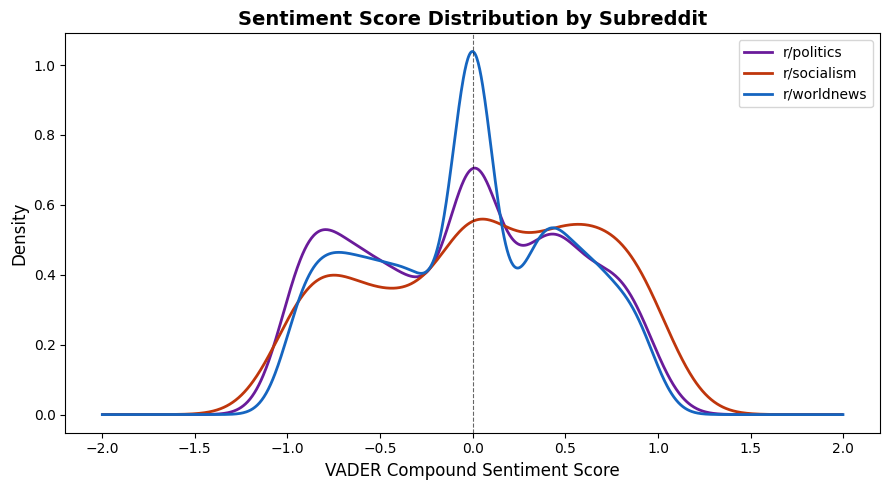

In [6]:
# Figure 3: Sentiment KDE Distribution
fig, ax = plt.subplots(figsize=(9, 5))
palette = {'worldnews': '#1565C0', 'politics': '#6A1B9A', 'socialism': '#BF360C'}
for subreddit, group in df.groupby('subreddit'):
    group['compound'].plot.kde(ax=ax, label=f'r/{subreddit}',
                                color=palette.get(subreddit, 'grey'), linewidth=2)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('VADER Compound Sentiment Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sentiment Score Distribution by Subreddit', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig3_sentiment_kde.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
STOPWORDS = set(['the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','it','its','this','that','are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','may','might','shall','can','need',
    'i','you','he','she','we','they','me','him','her','us','them','my','your','his','our',
    'their','what','which','who','when','where','why','how','all','each','every','both',
    'few','more','most','other','some','such','no','not','only','same','so','than','too',
    've','re','s','t','just','about','up','out','if','by','as','from','into','through',
    'http','https','www','reddit','com','gt','amp','get','got','go','also','like','one',
    'even','think','know','people','would','make','said','say','much','really','still',
    'back','way','well','then','thing','things','ll','didnt','dont','doesnt','isnt',
    'arent','wasnt','werent','hasnt','havent','hadnt','wont','wouldnt','couldnt',
    'shouldnt','thats','youre','theyre','hes','shes','weve','theyd','youd','hed',
    'rworldnews','rpolitics','rsocialism','imgur','wikipedia','yes','actually','going',
    'something','man','over','off','any','now','time','new','please','right','better',
    'good','bad','want','lot','isnt','though','mean','seems','point','help','again',
    'social','party','based','against','saying','work','years','money','taking','making',
    'having','doing','coming','used','use','see','put','look','come','take','give','two',
    'first','last','many','same','different','another','must','never','always','already',
    'since','while','after','before','between','without','within','during',
    'because','there','those','these','very','here','article','else','someone',
    'anything','own','made','high','year','news','world','shit','free','case',
    'believe','probably','talking','idea','less','support','stop','own','very'])
print("STOPWORDS updated.")

STOPWORDS updated.


In [15]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

df['tokens'] = df['body'].apply(preprocess)
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))
print("done:", df['tokens'].iloc[0][:8])

done: ['vast', 'majority', 'countries', 'recognize', 'state', 'palestine', 'btw', 'addition']


In [16]:
NUM_TOPICS = 5
PASSES = 10
subreddit_topics = {}
subreddit_models = {}

for subreddit in ['worldnews', 'politics', 'socialism']:
    sub_df = df[df['subreddit'] == subreddit]
    corpus_tokens = [t for t in sub_df['tokens'].tolist() if len(t) > 0]
    dictionary = corpora.Dictionary(corpus_tokens)
    dictionary.filter_extremes(no_below=3, no_above=0.7)
    bow_corpus = [dictionary.doc2bow(doc) for doc in corpus_tokens]
    lda = LdaModel(corpus=bow_corpus, id2word=dictionary, num_topics=NUM_TOPICS,
                   passes=PASSES, random_state=42, alpha='auto')
    topics = [[w for w, _ in lda.show_topic(i, topn=8)] for i in range(NUM_TOPICS)]
    subreddit_topics[subreddit] = topics
    subreddit_models[subreddit] = (lda, dictionary, bow_corpus)
    print(f"r/{subreddit}:")
    for i, t in enumerate(topics):
        print(f"  Topic {i+1}: {', '.join(t)}")
    print()

r/worldnews:
  Topic 1: yeah, space, war, ive, everyone, americans, police, russia
  Topic 2: country, west, lol, jews, government, israel, war, settlements
  Topic 3: oil, china, countries, prices, enough, russia, long, economy
  Topic 4: israel, children, palestinian, problem, justice, war, pretty, idf
  Topic 5: russia, ukraine, government, war, country, putin, account, russian

r/politics:
  Topic 1: gun, conservative, problem, city, nothing, guns, god, country
  Topic 2: teachers, agree, states, everyone, teacher, wife, either, cops
  Topic 3: law, white, obama, military, guy, racist, gop, police
  Topic 4: crime, public, service, cant, system, jobs, gun, government
  Topic 5: police, cops, officers, law, military, cop, arrest, crime

r/socialism:
  Topic 1: class, trans, police, left, working, gay, socialist, issues
  Topic 2: socialist, socialism, political, movement, government, let, politics, capitalism
  Topic 3: soviet, union, actual, ill, others, find, language, phonology
 

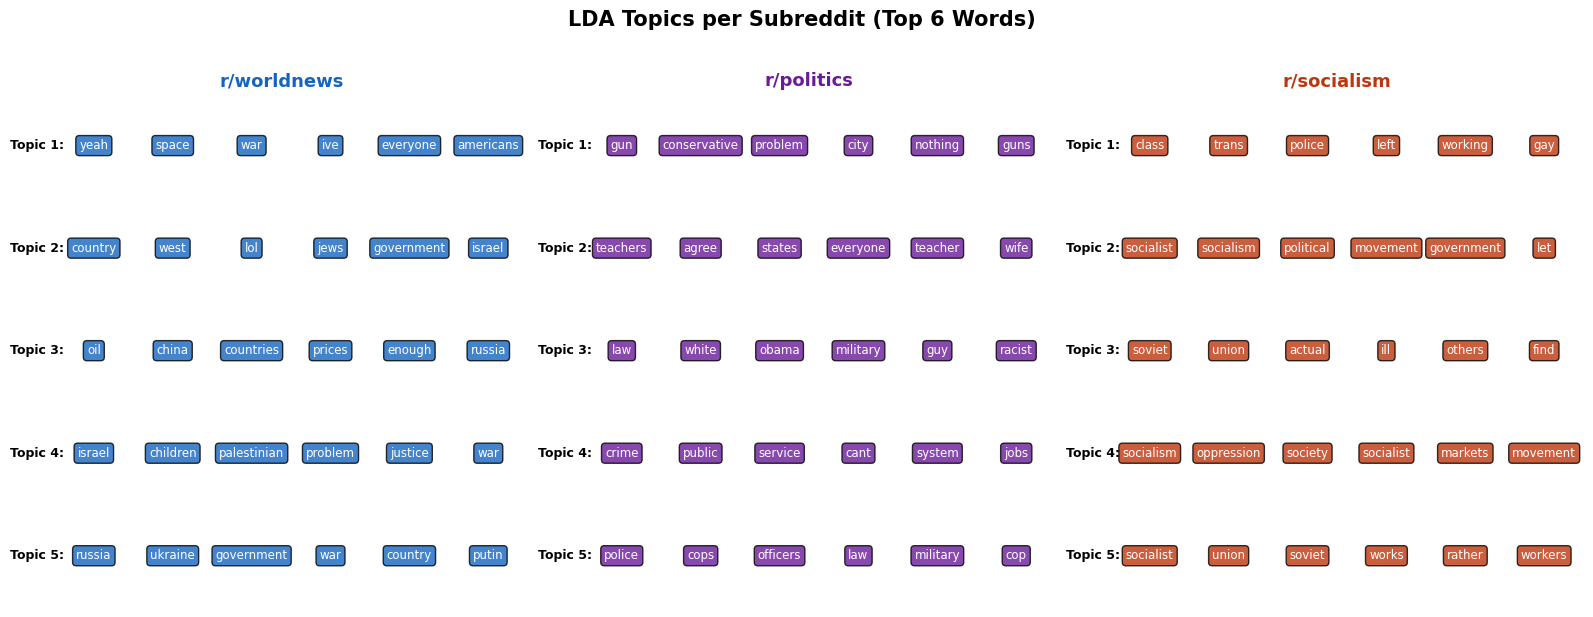

In [17]:
# Figure 4: LDA Topic Words
subreddit_colors = {'worldnews': '#1565C0', 'politics': '#6A1B9A', 'socialism': '#BF360C'}
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (subreddit, topics) in zip(axes, subreddit_topics.items()):
    color = subreddit_colors[subreddit]
    for i, topic_words in enumerate(topics):
        y = NUM_TOPICS - i
        ax.text(-0.05, y, f'Topic {i+1}:', fontsize=9, fontweight='bold',
                color='black', va='center', transform=ax.get_yaxis_transform())
        for j, word in enumerate(topic_words[:6]):
            ax.text(j * 0.16 + 0.12, y, word, fontsize=8.5, color='white',
                    va='center', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8),
                    transform=ax.get_yaxis_transform())
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, NUM_TOPICS + 0.5)
    ax.set_title(f'r/{subreddit}', fontsize=13, fontweight='bold', color=color)
    ax.axis('off')

fig.suptitle('LDA Topics per Subreddit (Top 6 Words)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig4_lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()

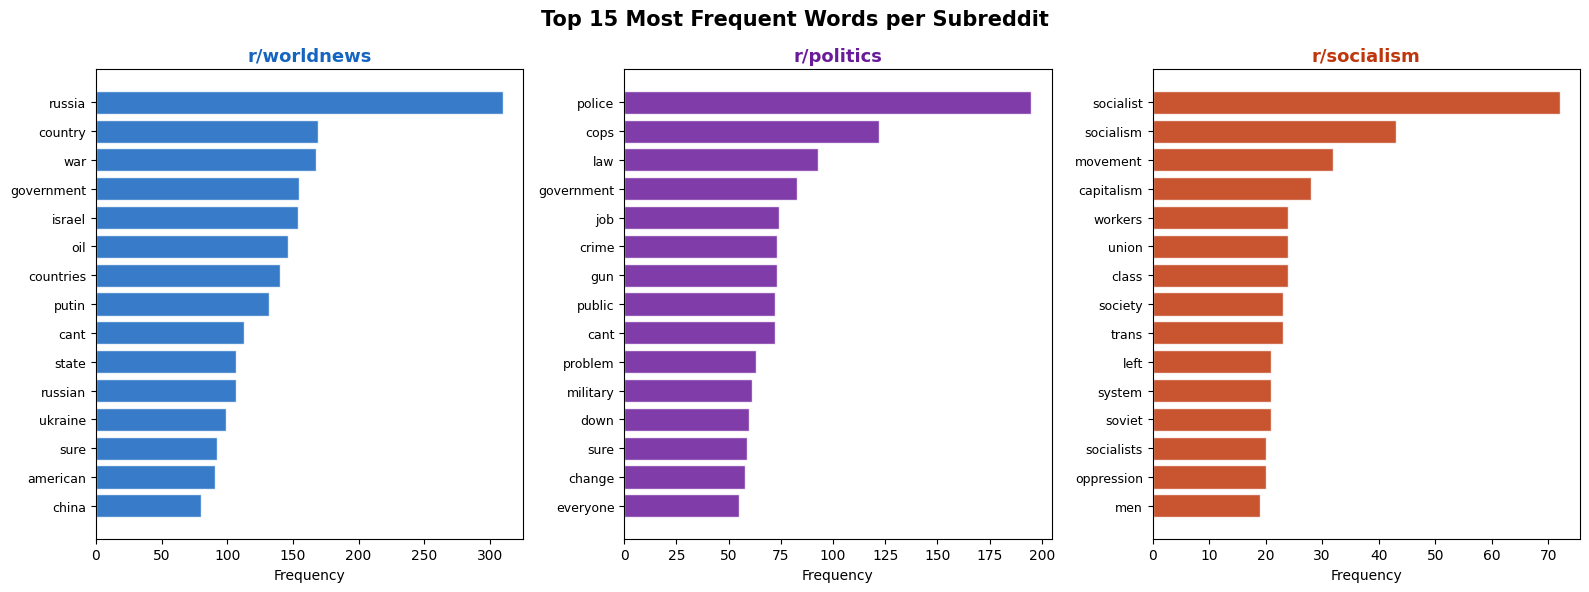

In [18]:
# Figure 5: Top 15 Most Frequent Words
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (subreddit, color) in zip(axes, subreddit_colors.items()):
    sub_tokens = df[df['subreddit'] == subreddit]['tokens'].explode()
    top_words = Counter(sub_tokens).most_common(15)
    words, counts = zip(*top_words)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'r/{subreddit}', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Frequency', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('Top 15 Most Frequent Words per Subreddit', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig5_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

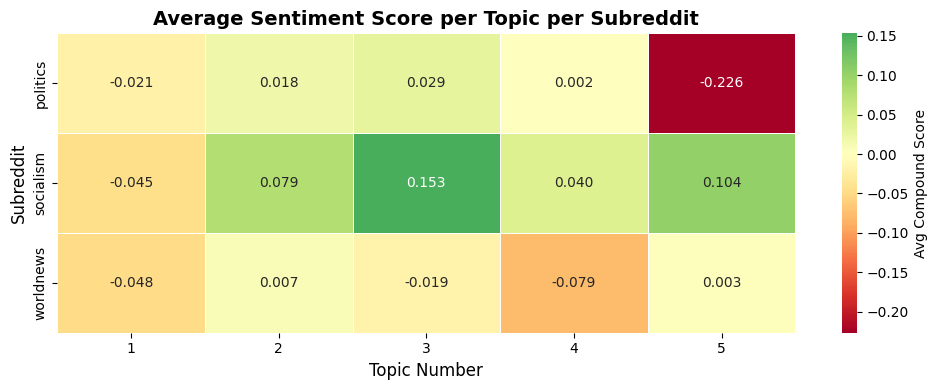

All figures saved to figures/ folder.


In [19]:
# Figure 6: Topic-Sentiment Heatmap
all_topic_sentiment = []
for subreddit in ['worldnews', 'politics', 'socialism']:
    lda, dictionary, bow_corpus = subreddit_models[subreddit]
    sub_df = df[df['subreddit'] == subreddit].copy().reset_index(drop=True)
    dominant_topics = []
    for doc in sub_df['tokens'].tolist():
        bow = dictionary.doc2bow(doc)
        if bow:
            topic_dist = lda.get_document_topics(bow)
            dominant = max(topic_dist, key=lambda x: x[1])[0] if topic_dist else 0
        else:
            dominant = 0
        dominant_topics.append(dominant + 1)
    sub_df['dominant_topic'] = dominant_topics
    all_topic_sentiment.append(sub_df[['subreddit', 'dominant_topic', 'compound']])

topic_sentiment_df = pd.concat(all_topic_sentiment)
pivot = topic_sentiment_df.groupby(['subreddit', 'dominant_topic'])['compound'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Compound Score'})
ax.set_xlabel('Topic Number', fontsize=12)
ax.set_ylabel('Subreddit', fontsize=12)
ax.set_title('Average Sentiment Score per Topic per Subreddit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig6_topic_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("All figures saved to figures/ folder.")